In [2]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from requests.packages import target
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from Classe_agent import Agent
from NetworkTopology import NetworkTopology

from model import Net,AlexNet
from metrics import*
from synchronize_weight import*

In [3]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
torch.version
torch.version.cuda
torch.cuda.is_available()

True

In [5]:
transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')

train_size = len(trainset)

split = train_size // 9
remainder = train_size % N_AGENT
print(remainder)

# Crée les parts
splits = [split] * N_AGENT
splits[0] += remainder  # Ajoute le reste au premier agent

print(f"Train size: {train_size}, Splits: {splits}, Sum: {sum(splits)}")


C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775


In [6]:
datasets_list = []
trainloaders_list = []
net_list = []
agent_list = []
split = train_size // N_AGENT

datasets_list = random_split(trainset, [split] * N_AGENT)#split dataset in N agent pefectly

for e in range(N_AGENT):

    trainloader = DataLoader(
        datasets_list[e],
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    trainloaders_list.append(trainloader)

    net = Net().to(DEVICE)
    #net = AlexNet(len(classes)).to(DEVICE)

    net_list.append(net)

    agent = Agent(
        agent_id=e,
        net=net_list[e],
        learning_rate=0.001,
        momentum=0.9,
        trainloader=trainloaders_list[e],
        testloader=testloader,
        device=DEVICE,
        neighbors = agent_list
    )
    agent_list.append(agent)





# Communication Graphe

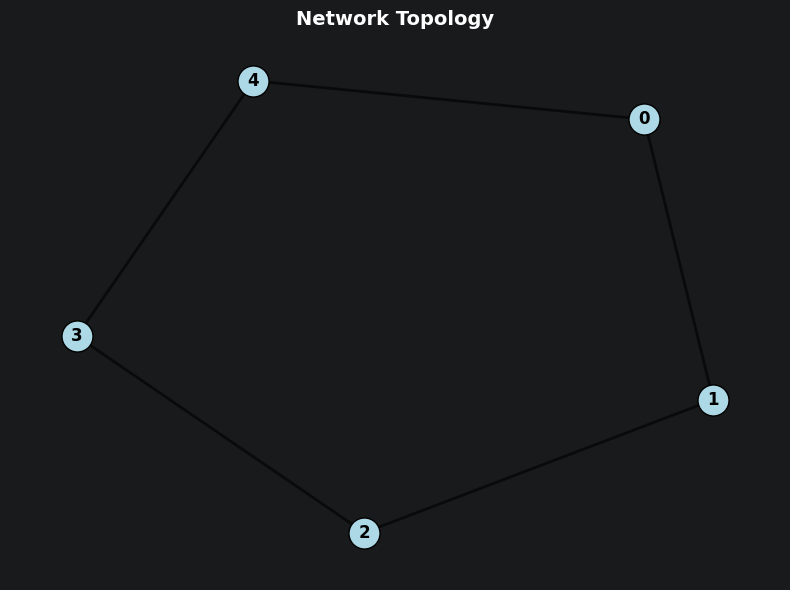

In [7]:
graph = NetworkTopology.cycle_graph(len(agent_list))

for agent_id, agent in enumerate(agent_list):
    graph.add_node(agent_id, agent=agent)

NetworkTopology.visualize_graph(graph)

In [8]:
loss_validate_list = []
accuracy_validate_list = []
metrics = ModelMetrics(agent_list)
for epoch in range(NUM_EPOCHES):

    threads_list = []

    # THREADS
    for agent in agent_list:
        thread = threading.Thread(
            target=agent.train_and_validate,
            args=[agent_list]
        )
        threads_list.append(thread)

    # Start des deux modèles
    for thread in threads_list:
        thread.start()

    print(f"Epoch {epoch+1}/{NUM_EPOCHES}")

    # Attendre la fin
    for thread in threads_list:
        thread.join()

    distances = Agent.node_weight_metric(agent_list)

    for agent, distance in zip(agent_list, distances):
        agent.total_distance_list.append(distance)

    # ============================================
    # Synchronisation des poids
    # ============================================

    #synchronize_models_average(agent_list)
    #synchronize_models_cycle(agent_list)
    consensu_algortyme(agent_list,graph,k)
    #synchronize_with_topology(agent_list,graph)

    metrics.print_all_metrics(epoch)

    metrics.log_metrics(epoch)

print("Les modèles ont fini l'entraînement")

Epoch 1/10
Agent 3 start
Agent 4 start
Agent 0 start
Agent 2 start
Agent 1 start
Model3 - Acc:11.64 % - Loss:2.2954018235206606 %
Model4 - Acc:13.2 % - Loss:2.290314277887344 %
Model0 - Acc:11.74 % - Loss:2.2980467455387115 %
Model2 - Acc:11.03 % - Loss:2.3004722757339477 %
Model1 - Acc:12.86 % - Loss:2.28557168841362 %
    → Distance moyenne après iter 1: 6.823361
    → Distance moyenne après iter 2: 3.479749
    → Distance moyenne après iter 3: 1.860332
    → Distance moyenne après iter 4: 1.002092
    → Distance moyenne après iter 5: 0.540366

📊 METRICS - Epoch 0

🔹 WEIGHT DISTANCES (Synchronisation)
----------------------------------------------------------------------
  Agent 0:     0.54  
  Agent 1:     0.55  
  Agent 2:     0.54  
  Agent 3:     0.54  
  Agent 4:     0.54  
  Average:      0.54

🔹 PARAMETER VARIANCE
----------------------------------------------------------------------
  conv1.weight                   Var = 0.000005  
  conv1.bias                     Var = 0.000

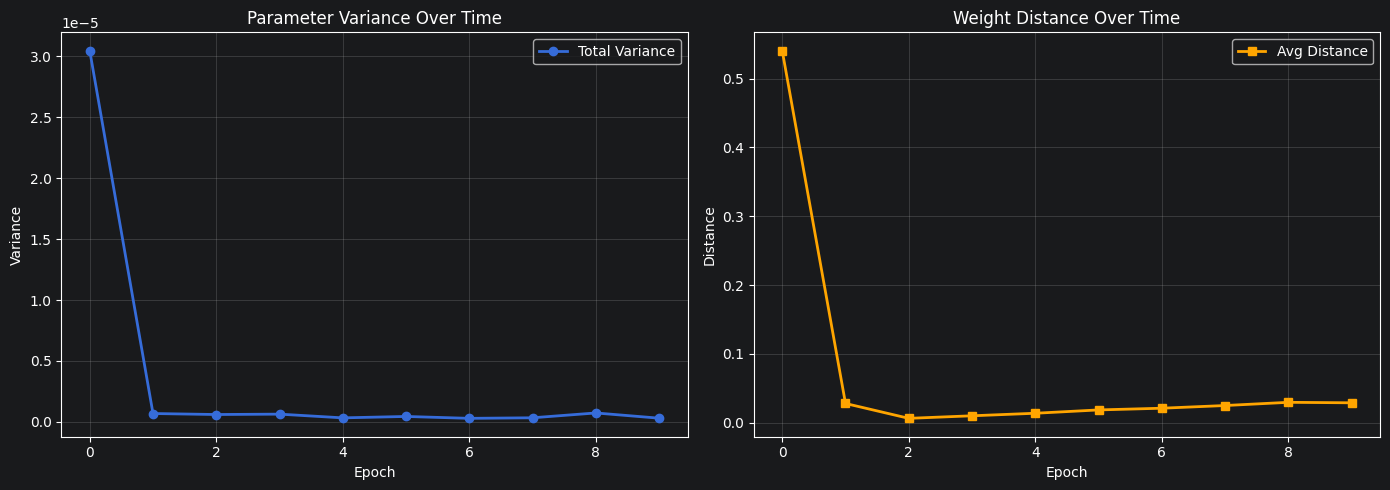

In [9]:
metrics.plot_history()

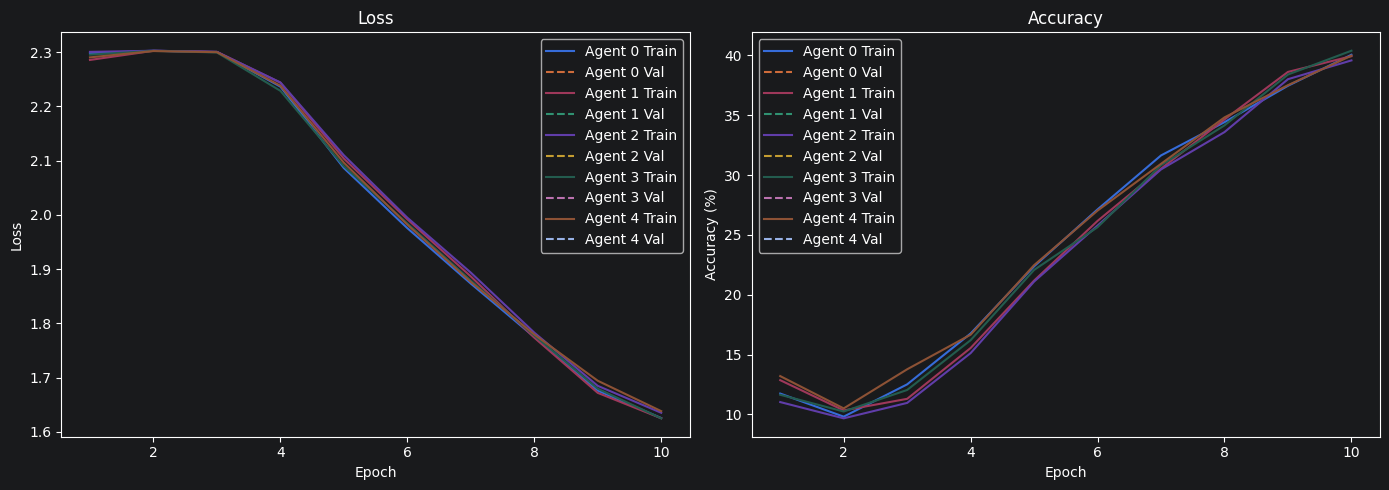

In [10]:
plot_all_agents_metrics(agent_list)

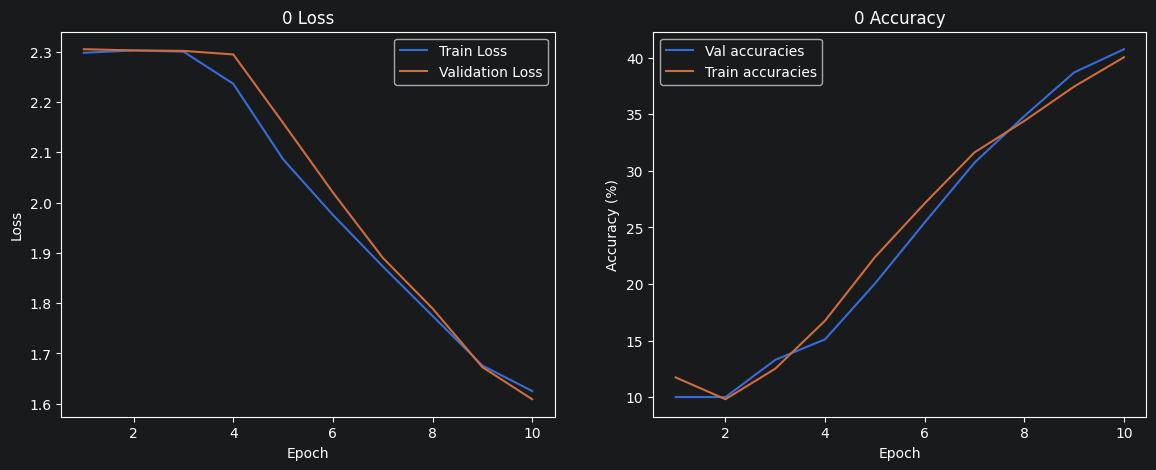

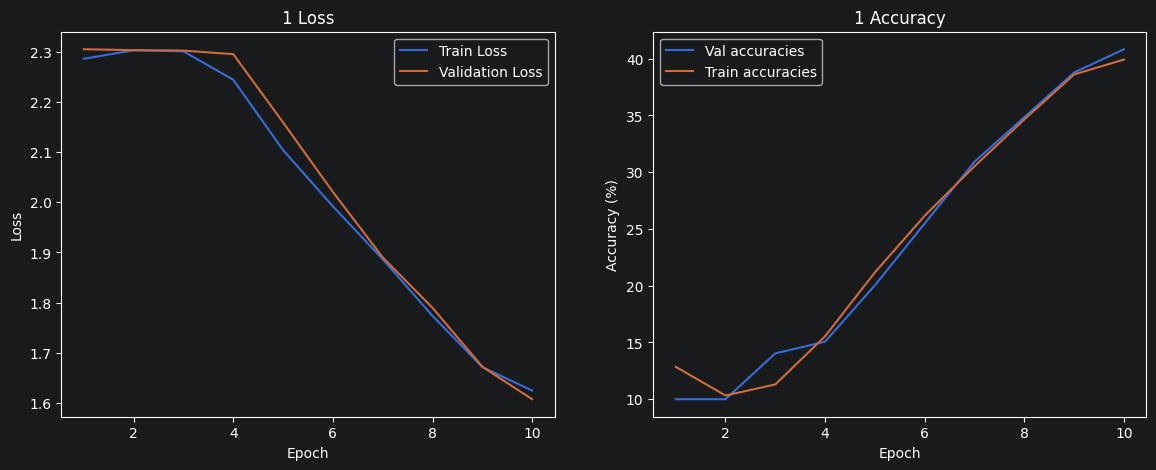

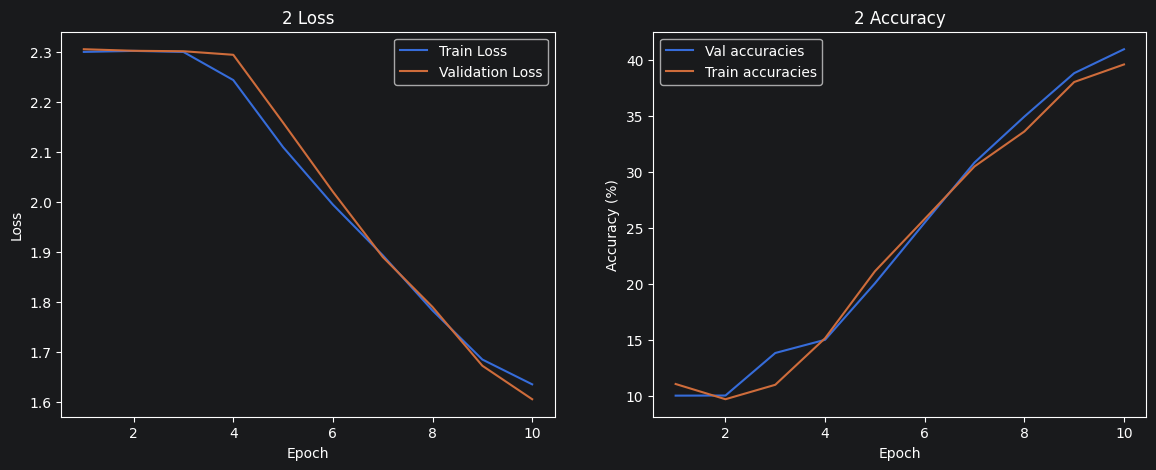

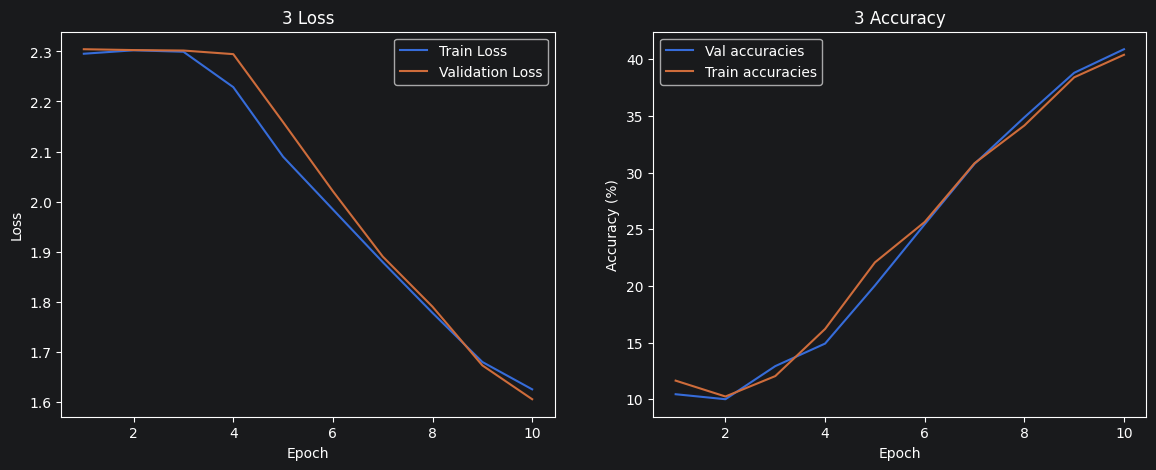

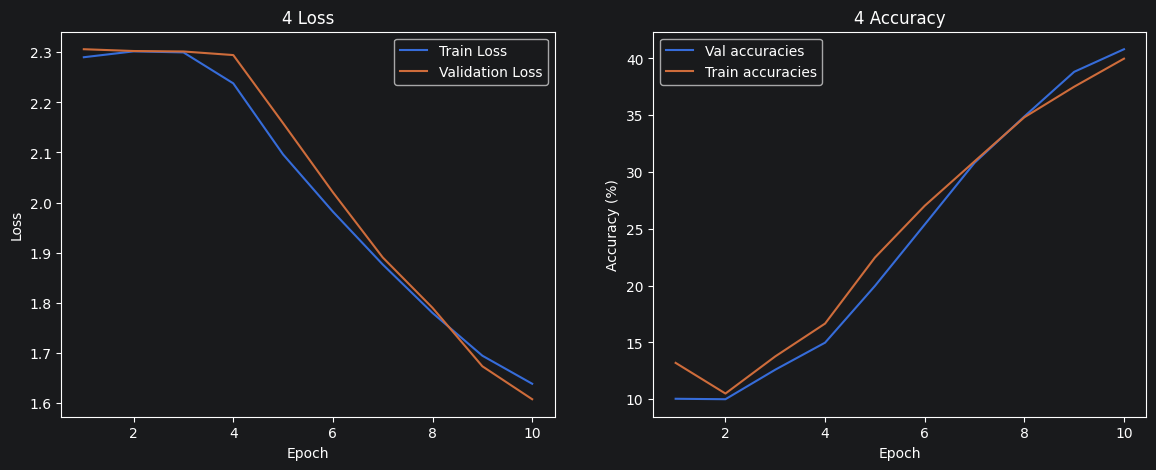

In [11]:
for agent in agent_list:

    agent.plot_metrics()

In [12]:
node_weight_metric(agent_list)


Agent 0
conv1.weight                   L2 distance = 0.003180
conv1.bias                     L2 distance = 0.000908
conv2.weight                   L2 distance = 0.004933
conv2.bias                     L2 distance = 0.000301
fc1.weight                     L2 distance = 0.009778
fc1.bias                       L2 distance = 0.000361
fc2.weight                     L2 distance = 0.004849
fc2.bias                       L2 distance = 0.000488
fc3.weight                     L2 distance = 0.004120
fc3.bias                       L2 distance = 0.000790
Distance totale = 0.029706

Agent 1
conv1.weight                   L2 distance = 0.003435
conv1.bias                     L2 distance = 0.000902
conv2.weight                   L2 distance = 0.005173
conv2.bias                     L2 distance = 0.000231
fc1.weight                     L2 distance = 0.009277
fc1.bias                       L2 distance = 0.000234
fc2.weight                     L2 distance = 0.004454
fc2.bias                       L2 dis

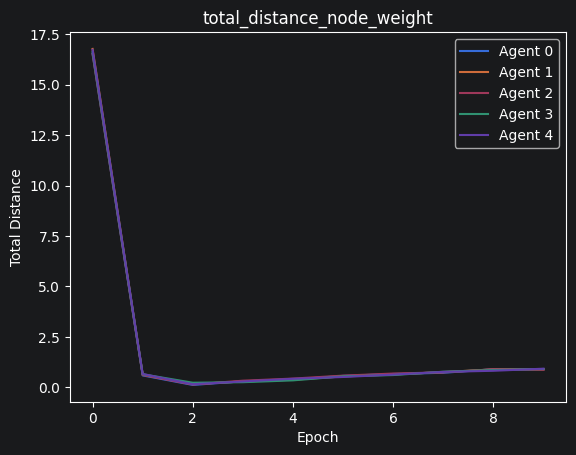

In [13]:
plot_all_agent_node_weight_metric(agent_list)

In [14]:
for agent in agent_list:
    print("Agent",agent.id)
    #print(agent.loss_validate_list)
    print(agent.val_losses)
    #print(agent.accuracy_validate_list)
    print(agent.val_accuracies)

Agent 0
[2.305119649171829, 2.302758082151413, 2.3018102436065675, 2.2947319538593294, 2.1586101331710816, 2.0202702475786207, 1.8904044127464295, 1.789566971898079, 1.6728246143460275, 1.608958977341652]
[10.0, 10.0, 13.29, 15.11, 20.03, 25.44, 30.73, 34.85, 38.71, 40.76]
Agent 1
[2.304589174747467, 2.3027424552440645, 2.301819096326828, 2.2947720589637757, 2.158840028166771, 2.0203251011371615, 1.8902027515172959, 1.7896384028196335, 1.6723584297299385, 1.607698366999626]
[10.0, 10.0, 14.04, 15.07, 20.04, 25.49, 30.93, 34.85, 38.79, 40.84]
Agent 2
[2.3058548002243042, 2.302727950334549, 2.3018116772174837, 2.2946962826251984, 2.158923611998558, 2.0205641169548034, 1.890019845366478, 1.7898259873390199, 1.672233254134655, 1.6052132020592689]
[9.99, 10.0, 13.8, 14.98, 20.02, 25.45, 30.82, 34.92, 38.8, 40.94]
Agent 3
[2.304427543640137, 2.302717181444168, 2.301797329902649, 2.2946089360713957, 2.1587441389560698, 2.0206734281778336, 1.8901250556707383, 1.7898396862745285, 1.672579335570